# 02 - Preprocessing

This notebook demonstrates the image preprocessing pipeline defined in
`task2_3_4_cv_quality/src/preprocess.py`.

- **Training** uses random augmentation (flip, rotation, colour jitter) to improve generalisation.
- **Validation / test** use a deterministic pipeline (resize + normalise only) so evaluation is reproducible.
- All images are resized to the configured `image_size` and normalised with ImageNet statistics before being passed to the model.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "config.yaml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from task2_3_4_cv_quality.src.preprocess import get_transforms, load_config

cfg = load_config()
cfg

{'data_root': 'task2_3_4_cv_quality/data/raw/dataset',
 'train_dir': 'task2_3_4_cv_quality/data/raw/dataset/Train',
 'test_dir': 'task2_3_4_cv_quality/data/raw/dataset/Test',
 'image_size': 224,
 'mean': [0.485, 0.456, 0.406],
 'std': [0.229, 0.224, 0.225]}

Sample class : freshapples
Sample path  : task2_3_4_cv_quality\data\raw\dataset\Train\freshapples\a_f001.png
Original size: (470, 386)


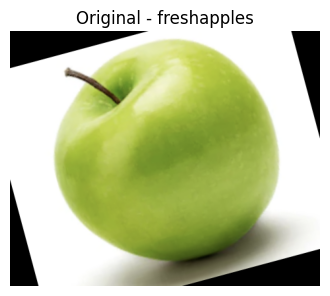

In [2]:
train_dir = REPO_ROOT / cfg["train_dir"]
class_dirs = sorted(p for p in train_dir.iterdir() if p.is_dir())

sample_path = None
for cls_dir in class_dirs:
    images = sorted(p for p in cls_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
    if images:
        sample_path = images[0]
        break

assert sample_path is not None, f"No images found under {train_dir}"
sample_image = Image.open(sample_path).convert("RGB")
print(f"Sample class : {sample_path.parent.name}")
print(f"Sample path  : {sample_path.relative_to(REPO_ROOT)}")
print(f"Original size: {sample_image.size}")

plt.figure(figsize=(4, 4))
plt.imshow(sample_image)
plt.title(f"Original - {sample_path.parent.name}")
plt.axis("off")
plt.show()

In [3]:
mean = np.array(cfg["mean"])
std = np.array(cfg["std"])


def tensor_to_image(tensor: torch.Tensor) -> np.ndarray:
    """De-normalise a CHW tensor and return an HWC uint8-ready float array."""
    img = tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * std + mean
    return np.clip(img, 0.0, 1.0)

## Training transforms (random augmentation)

Calling `get_transforms('train')` several times on the same image produces different
augmented views each time.

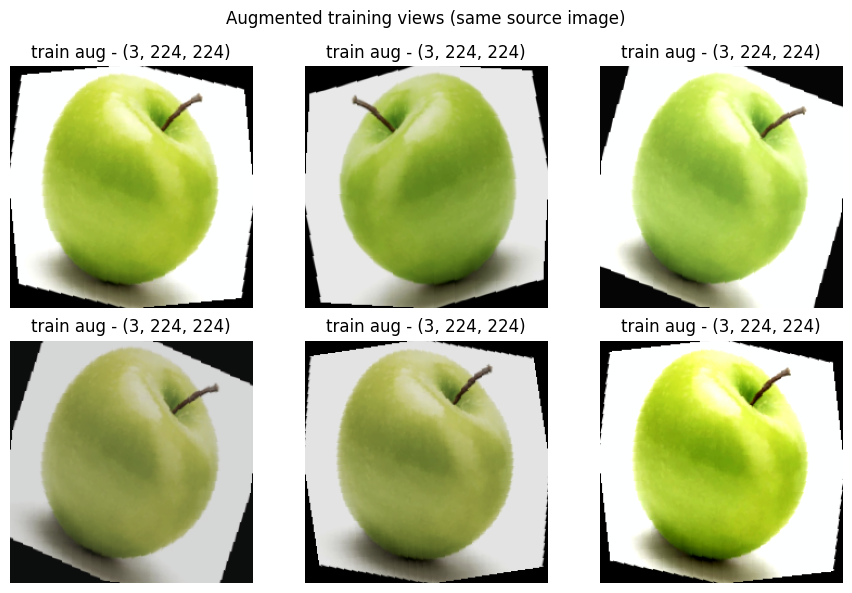

In [4]:
train_tf = get_transforms("train")

n_aug = 6
torch.manual_seed(0)

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax in axes.flat:
    augmented = train_tf(sample_image)
    ax.imshow(tensor_to_image(augmented))
    ax.set_title(f"train aug - {tuple(augmented.shape)}")
    ax.axis("off")
fig.suptitle("Augmented training views (same source image)")
fig.tight_layout()
plt.show()

## Validation / test transforms (deterministic)

`get_transforms('val')` and `get_transforms('test')` are identical and deterministic:
resize + `ToTensor` + `Normalize`. Running them twice produces the same tensor.

val == val  : True
val == test : True
tensor shape: (3, 224, 224)


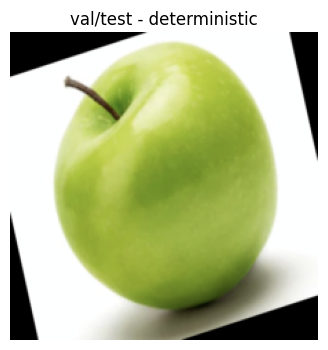

In [5]:
val_tf = get_transforms("val")
test_tf = get_transforms("test")

val_tensor_a = val_tf(sample_image)
val_tensor_b = val_tf(sample_image)
test_tensor = test_tf(sample_image)

print("val == val  :", torch.allclose(val_tensor_a, val_tensor_b))
print("val == test :", torch.allclose(val_tensor_a, test_tensor))
print("tensor shape:", tuple(val_tensor_a.shape))

plt.figure(figsize=(4, 4))
plt.imshow(tensor_to_image(val_tensor_a))
plt.title("val/test - deterministic")
plt.axis("off")
plt.show()

## Summary

- Training transforms introduce stochastic augmentation to help the model generalise beyond the exact training images.
- Validation and test transforms are deterministic so metrics are comparable across runs.
- Every split resizes to `image_size` and normalises with the configured ImageNet `mean` / `std`, matching the input statistics expected by common pretrained backbones.

# Class imbalance

Class imbalance occurs when some classes have substantially fewer training
samples than others. Models trained on imbalanced data tend to:

- under-learn minority classes (low recall on them),
- inflate overall accuracy because the majority classes dominate the loss,
- produce biased decision boundaries that favour the majority classes.

We address this in two passes:

1. `preprocess.check_class_balance(...)` counts samples per class and
   **flags** any class below `imbalance_threshold` (default 70%) of the
   largest class.
2. `train.create_dataloaders(...)` builds a `WeightedRandomSampler` with
   weights proportional to `1 / class_count`, and uses it **only** on the
   training `DataLoader`. Validation and test loaders stay un-sampled and
   un-shuffled so evaluation reflects the real class distribution.

In [ ]:
from collections import Counter

from torchvision.datasets import ImageFolder

from task2_3_4_cv_quality.src.preprocess import check_class_balance

raw_train_dataset = ImageFolder(str(REPO_ROOT / cfg["train_dir"]))
full_class_counts = {
    name: int(Counter(raw_train_dataset.targets).get(idx, 0))
    for idx, name in enumerate(raw_train_dataset.classes)
}

full_report = check_class_balance(full_class_counts)

In [ ]:
sorted_items = sorted(full_report.class_counts.items(), key=lambda kv: kv[1], reverse=True)
names = [k for k, _ in sorted_items]
counts = [v for _, v in sorted_items]
cutoff = full_report.threshold * full_report.largest_class_count
colors = ["#d9534f" if n < cutoff else "#5cb85c" for n in counts]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(names, counts, color=colors)
ax.axhline(cutoff, color="black", linestyle="--", linewidth=1,
           label=f"{full_report.threshold:.0%} of largest ({int(cutoff)})")
ax.set_ylabel("Number of training images")
ax.set_title("Training class distribution (red = flagged as imbalanced)")
ax.tick_params(axis="x", rotation=60)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
ax.legend()
fig.tight_layout()
plt.show()

## Fix: `WeightedRandomSampler` on the training loader only

`task2_3_4_cv_quality/src/train.py` exposes `create_dataloaders()` which:

- splits the `Train` directory into reproducible train / val subsets
  (seeded by `random_seed`) with **different** transforms applied to
  each subset,
- reports the class balance of the **training subset** (not the full
  `Train` directory) via `check_class_balance`,
- builds a `WeightedRandomSampler` whose per-sample weight is
  `1 / count[class]`, so minority classes are drawn proportionally more
  often during training,
- attaches the sampler to `train_loader` (and therefore does **not** set
  `shuffle=True` — the two are mutually exclusive),
- returns plain, unshuffled `val_loader` and `test_loader` objects so
  evaluation reflects the true, unbalanced class distribution.

In [ ]:
from torch.utils.data import WeightedRandomSampler

from task2_3_4_cv_quality.src.train import create_dataloaders

bundle = create_dataloaders()

print()
print("train_loader sampler :", type(bundle.train_loader.sampler).__name__)
print("val_loader   sampler :", type(bundle.val_loader.sampler).__name__)
print("test_loader  sampler :", type(bundle.test_loader.sampler).__name__)
assert isinstance(bundle.train_loader.sampler, WeightedRandomSampler), \
    "train_loader must use WeightedRandomSampler"
assert not isinstance(bundle.val_loader.sampler, WeightedRandomSampler), \
    "val_loader must NOT be oversampled"
assert not isinstance(bundle.test_loader.sampler, WeightedRandomSampler), \
    "test_loader must NOT be oversampled"
print("OK - oversampling is applied only to the training loader.")

In [ ]:
sampler = bundle.train_loader.sampler
drawn_indices = list(iter(sampler))

base_targets = bundle.train_loader.dataset.dataset.targets
subset_indices = bundle.train_loader.dataset.indices
drawn_labels = [int(base_targets[subset_indices[i]]) for i in drawn_indices]
drawn_counter = Counter(drawn_labels)

print("Effective per-epoch sample counts after WeightedRandomSampler:")
original = bundle.train_class_counts
name_width = max(len(n) for n in bundle.classes)
for idx, name in enumerate(bundle.classes):
    before = original[name]
    after = drawn_counter.get(idx, 0)
    print(f"  {name:<{name_width}}  before: {before:5d}   after: {after:5d}")